In [1]:
# Libraries and modules
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, f1_score, matthews_corrcoef, auc, precision_recall_curve, roc_curve, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import VarianceThreshold, SelectKBest, RFE, RFECV, SelectFromModel
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn import tree

In [2]:
# Step 1: Read the original data files
mofa_all_omic = pd.read_csv("combined_MOFA_data.csv", index_col=0)

# Check the dimensions of the dataframes
print("mofa_all_omic shape:", mofa_all_omic.shape)

mofa_all_omic shape: (960, 301)


In [3]:
mofa_all_omic.head()

,BCL11A,GABRP,VGLL1,GZMB,PSAT1,SFRP1,CD38,FCRL5,PLA2G2D,LAMP3,...,cg11719784,cg01637734,cg18328334,cg00497084,cg02554564,cg17240454,cg16112157,cg01078434,cg22294908,Subtype
Sample.ID,,,,,,,,,,,,,,,,,,,,,
TCGA.3C.AAAU.01,50.953883,697.495383,39.077985,4.112846,47.116198,1220.731670,14.287884,26.286038,14.832268,48.930949,...,0.290554,0.634340,0.200251,0.604722,0.220210,0.359977,0.492084,0.571924,0.811989,BRCA_LumA
TCGA.3C.AALI.01,57.340783,727.257383,46.690785,129.579546,522.449998,849.200670,114.043484,101.126738,137.862868,297.802349,...,0.832641,0.695272,0.254896,0.660118,0.614852,0.463080,0.513511,0.527302,0.443548,BRCA_Her2
TCGA.3C.AALJ.01,41.573283,700.432583,39.077985,78.672846,251.187998,814.604470,40.647484,62.903338,89.497368,204.517349,...,0.409988,0.397107,0.324885,0.674473,0.314075,0.539119,0.749842,0.898521,0.677289,BRCA_LumB
TCGA.3C.AALK.01,68.818683,1330.650083,63.074685,27.420246,61.258898,1984.174670,28.634884,62.151638,39.935668,151.337349,...,0.626335,0.774772,0.310764,0.743165,0.441131,0.499728,0.740194,0.724721,0.930994,BRCA_LumA
TCGA.4H.AAAK.01,88.921160,1779.518296,127.197819,42.606007,185.430706,2569.709923,31.238872,56.984463,54.945845,161.905653,...,0.548786,0.612610,0.279918,0.654427,0.402885,0.459013,0.617586,0.698657,0.701616,BRCA_LumA


In [4]:
mofa_all_omic.describe()

,BCL11A,GABRP,VGLL1,GZMB,PSAT1,SFRP1,CD38,FCRL5,PLA2G2D,LAMP3,...,cg19099213,cg11719784,cg01637734,cg18328334,cg00497084,cg02554564,cg17240454,cg16112157,cg01078434,cg22294908
count,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,...,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000
mean,164.650190,3230.846897,259.768548,91.638902,366.697293,3653.631412,73.470976,96.251166,125.733946,323.458755,...,0.669826,0.542885,0.616237,0.270753,0.659039,0.400634,0.468521,0.614021,0.672025,0.715964
std,315.142872,8144.474344,1080.346917,181.371805,736.639622,8290.160318,133.651011,227.594172,360.297497,688.960655,...,0.212166,0.207045,0.266499,0.162638,0.179051,0.161975,0.146569,0.203034,0.240994,0.214740
min,-62.429868,-2577.601075,-190.698142,-42.557306,-457.876344,-2062.157723,-25.417779,-50.910182,-141.163106,-1091.996708,...,0.062091,-0.009714,-0.008911,-0.026150,0.096925,0.050061,0.101111,0.050428,0.040338,0.071094
25%,13.767062,110.036273,0.312827,9.850771,26.698463,254.004692,7.881675,8.952435,8.888376,56.121886,...,0.511817,0.374839,0.399873,0.158023,0.536193,0.286860,0.366480,0.467066,0.476984,0.548022
50%,39.001279,419.313940,22.801063,25.328795,66.867238,800.630262,25.737154,25.817425,25.325004,125.927648,...,0.699226,0.525575,0.624838,0.227344,0.671820,0.378345,0.448938,0.630847,0.723145,0.762864
75%,148.916431,1240.085336,54.285426,83.120133,328.424182,3143.689968,72.435885,81.417941,91.726405,314.913921,...,0.860931,0.740363,0.852794,0.342322,0.805570,0.485431,0.550253,0.777920,0.892599,0.903791
max,3585.642452,69083.401090,17160.573440,1901.633614,6990.247960,107611.404400,1176.613721,3679.409118,5674.331461,13068.376090,...,1.059075,0.973348,1.102972,0.888522,1.023395,0.968716,0.932377,1.002556,1.034461,1.082452


In [5]:
mofa_all_omic.dtypes.value_counts()

float64    300
object       1
Name: count, dtype: int64

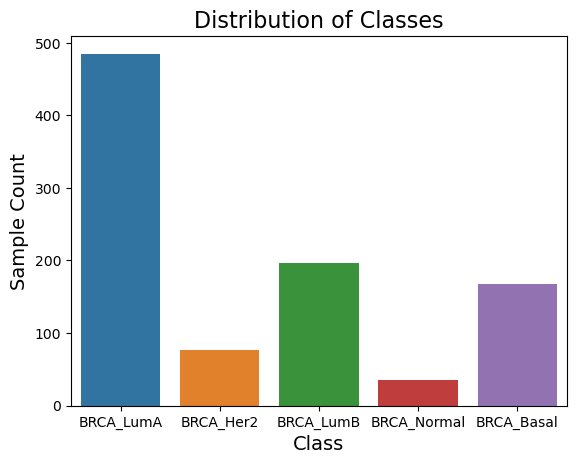

In [6]:
# Assuming 'subtype' is the column with your labels
sns.countplot(data=mofa_all_omic, x='Subtype')  # Adjust 'subtype' if your label column has a different name
plt.title("Distribution of Classes", fontsize=16)
plt.xlabel('Class', fontsize=14)
plt.ylabel('Sample Count', fontsize=14)
plt.show()

In [7]:
# Step 1: Read the original data files
mofa_Transcriptomics = pd.read_csv("MOFA_Transcriptome_matrix.csv", index_col=0)

# Check the dimensions of the dataframes
print("mofa_Transcriptomics shape:", mofa_Transcriptomics.shape)

mofa_Transcriptomics shape: (960, 101)


In [8]:
mofa_Transcriptomics.head()

,BCL11A,GABRP,VGLL1,GZMB,PSAT1,SFRP1,CD38,FCRL5,PLA2G2D,LAMP3,...,IL2RG,PKP1,ZNF831,ART3,CD247,CD7,LTB,GZMK,KLK6,Subtype
Sample.ID,,,,,,,,,,,,,,,,,,,,,
TCGA.3C.AAAU.01,50.953883,697.495383,39.077985,4.112846,47.116198,1220.731670,14.287884,26.286038,14.832268,48.930949,...,104.947383,189.334404,5.228375,13.686963,8.203627,12.366333,28.336003,2.347815,64.356805,BRCA_LumA
TCGA.3C.AALI.01,57.340783,727.257383,46.690785,129.579546,522.449998,849.200670,114.043484,101.126738,137.862868,297.802349,...,873.372383,423.523804,45.046175,16.604863,186.385027,242.849033,276.019603,227.369715,64.716605,BRCA_Her2
TCGA.3C.AALJ.01,41.573283,700.432583,39.077985,78.672846,251.187998,814.604470,40.647484,62.903338,89.497368,204.517349,...,803.158383,179.009704,68.272175,15.155463,161.070027,163.705033,271.595602,332.079715,60.910205,BRCA_LumB
TCGA.3C.AALK.01,68.818683,1330.650083,63.074685,27.420246,61.258898,1984.174670,28.634884,62.151638,39.935668,151.337349,...,494.521383,303.324804,32.468075,14.583463,102.335027,94.917033,221.638602,84.202815,154.414505,BRCA_LumA
TCGA.4H.AAAK.01,88.921160,1779.518296,127.197819,42.606007,185.430706,2569.709923,31.238872,56.984463,54.945845,161.905653,...,447.450714,645.190230,30.116198,56.600764,79.421105,73.716630,164.396734,120.417077,232.774610,BRCA_LumA


In [9]:
mofa_Transcriptomics.describe()

,BCL11A,GABRP,VGLL1,GZMB,PSAT1,SFRP1,CD38,FCRL5,PLA2G2D,LAMP3,...,CTLA4,IL2RG,PKP1,ZNF831,ART3,CD247,CD7,LTB,GZMK,KLK6
count,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,...,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000
mean,164.650190,3230.846897,259.768548,91.638902,366.697293,3653.631412,73.470976,96.251166,125.733946,323.458755,...,48.966144,660.553903,937.696576,46.299826,104.696066,112.230037,107.683998,220.026731,176.503243,444.090781
std,315.142872,8144.474344,1080.346917,181.371805,736.639622,8290.160318,133.651011,227.594172,360.297497,688.960655,...,68.696830,916.584469,2642.094671,80.113552,562.842291,155.098063,164.954267,733.038558,300.217296,1837.948619
min,-62.429868,-2577.601075,-190.698142,-42.557306,-457.876344,-2062.157723,-25.417779,-50.910182,-141.163106,-1091.996708,...,-44.964736,-210.875279,-914.318876,-7.140787,-146.957929,-83.773176,-263.267616,-381.343246,-262.533592,-627.307169
25%,13.767062,110.036273,0.312827,9.850771,26.698463,254.004692,7.881675,8.952435,8.888376,56.121886,...,9.436806,178.537335,75.457971,8.615311,-1.216784,27.201020,24.070334,33.333766,31.419730,6.939252
50%,39.001279,419.313940,22.801063,25.328795,66.867238,800.630262,25.737154,25.817425,25.325004,125.927648,...,24.758971,365.661564,235.569702,21.639881,6.897137,64.392563,51.416790,78.619658,81.834635,45.134451
75%,148.916431,1240.085336,54.285426,83.120133,328.424182,3143.689968,72.435885,81.417941,91.726405,314.913921,...,60.608964,744.226841,697.020947,50.256914,24.425876,131.163345,114.559278,179.958409,194.445734,107.920807
max,3585.642452,69083.401090,17160.573440,1901.633614,6990.247960,107611.404400,1176.613721,3679.409118,5674.331461,13068.376090,...,826.393891,10769.447770,38148.854600,1132.724922,12187.842070,1553.691218,1527.597840,16572.638920,4529.852841,24909.908090


In [10]:
mofa_Transcriptomics.dtypes.value_counts()

float64    100
object       1
Name: count, dtype: int64

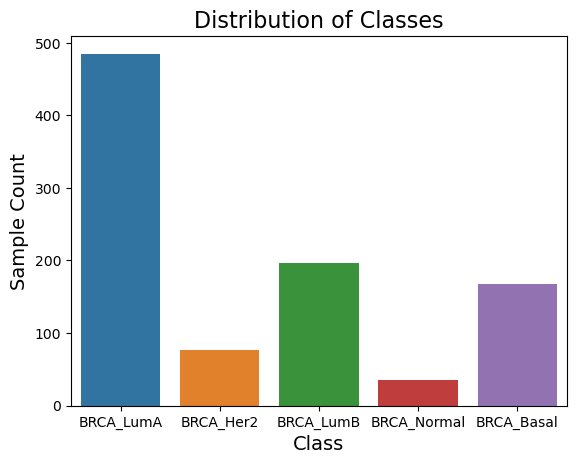

In [11]:
# Assuming 'subtype' is the column with your labels
sns.countplot(data=mofa_Transcriptomics, x='Subtype')  # Adjust 'subtype' if your label column has a different name
plt.title("Distribution of Classes", fontsize=16)
plt.xlabel('Class', fontsize=14)
plt.ylabel('Sample Count', fontsize=14)
plt.show()

In [12]:
# Step 1: Read the original data files
mofa_epigenomics = pd.read_csv("MOFA_epigenome_matrix.csv", index_col=0)

# Check the dimensions of the dataframes
print("mofa_epigenomics shape:", mofa_epigenomics.shape)

mofa_epigenomics shape: (960, 101)


In [13]:
mofa_epigenomics.head()

,cg02880679,cg17095936,cg19589427,cg08658594,cg02399455,cg04457051,cg10334928,cg08057475,cg21137417,cg24512973,...,cg11719784,cg01637734,cg18328334,cg00497084,cg02554564,cg17240454,cg16112157,cg01078434,cg22294908,Subtype
Sample.ID,,,,,,,,,,,,,,,,,,,,,
TCGA.3C.AAAU.01,0.672736,0.329681,0.416961,0.286737,0.320910,0.302859,0.398921,0.316272,0.364036,0.090226,...,0.290554,0.634340,0.200251,0.604722,0.220210,0.359977,0.492084,0.571924,0.811989,BRCA_LumA
TCGA.3C.AALI.01,0.219838,0.857900,0.532235,0.584784,0.931005,0.439304,0.431001,0.966207,0.451675,0.747501,...,0.832641,0.695272,0.254896,0.660118,0.614852,0.463080,0.513511,0.527302,0.443548,BRCA_Her2
TCGA.3C.AALJ.01,0.864944,0.549434,0.521313,0.767421,0.541205,0.614726,0.480071,0.660990,0.668845,0.570928,...,0.409988,0.397107,0.324885,0.674473,0.314075,0.539119,0.749842,0.898521,0.677289,BRCA_LumB
TCGA.3C.AALK.01,0.478490,0.399554,0.524671,0.751375,0.587054,0.665253,0.537946,0.707610,0.733018,0.289547,...,0.626335,0.774772,0.310764,0.743165,0.441131,0.499728,0.740194,0.724721,0.930994,BRCA_LumA
TCGA.4H.AAAK.01,0.574415,0.525641,0.507335,0.617560,0.601618,0.498134,0.470060,0.655402,0.541992,0.411302,...,0.548786,0.612610,0.279918,0.654427,0.402885,0.459013,0.617586,0.698657,0.701616,BRCA_LumA


In [14]:
mofa_epigenomics.describe()

,cg02880679,cg17095936,cg19589427,cg08658594,cg02399455,cg04457051,cg10334928,cg08057475,cg21137417,cg24512973,...,cg19099213,cg11719784,cg01637734,cg18328334,cg00497084,cg02554564,cg17240454,cg16112157,cg01078434,cg22294908
count,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,...,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000
mean,0.560334,0.533807,0.505734,0.593656,0.597068,0.499389,0.463314,0.659880,0.553209,0.398239,...,0.669826,0.542885,0.616237,0.270753,0.659039,0.400634,0.468521,0.614021,0.672025,0.715964
std,0.255653,0.279129,0.232593,0.222571,0.225999,0.224579,0.219349,0.231219,0.226825,0.246413,...,0.212166,0.207045,0.266499,0.162638,0.179051,0.161975,0.146569,0.203034,0.240994,0.214740
min,0.027003,-0.056749,0.000852,-0.038789,0.060935,0.011372,0.003658,0.066167,-0.004640,0.003511,...,0.062091,-0.009714,-0.008911,-0.026150,0.096925,0.050061,0.101111,0.050428,0.040338,0.071094
25%,0.356466,0.310660,0.327440,0.423843,0.424260,0.337331,0.299975,0.476996,0.387088,0.220640,...,0.511817,0.374839,0.399873,0.158023,0.536193,0.286860,0.366480,0.467066,0.476984,0.548022
50%,0.538909,0.477216,0.469618,0.578218,0.576416,0.471576,0.426148,0.664805,0.538290,0.327105,...,0.699226,0.525575,0.624838,0.227344,0.671820,0.378345,0.448938,0.630847,0.723145,0.762864
75%,0.786011,0.804062,0.679024,0.789410,0.786959,0.657733,0.602413,0.876805,0.724527,0.506700,...,0.860931,0.740363,0.852794,0.342322,0.805570,0.485431,0.550253,0.777920,0.892599,0.903791
max,1.167861,1.146514,1.090691,1.148253,1.012292,1.128944,1.048249,1.098884,1.095961,1.113204,...,1.059075,0.973348,1.102972,0.888522,1.023395,0.968716,0.932377,1.002556,1.034461,1.082452


In [15]:
mofa_epigenomics.dtypes.value_counts()

float64    100
object       1
Name: count, dtype: int64

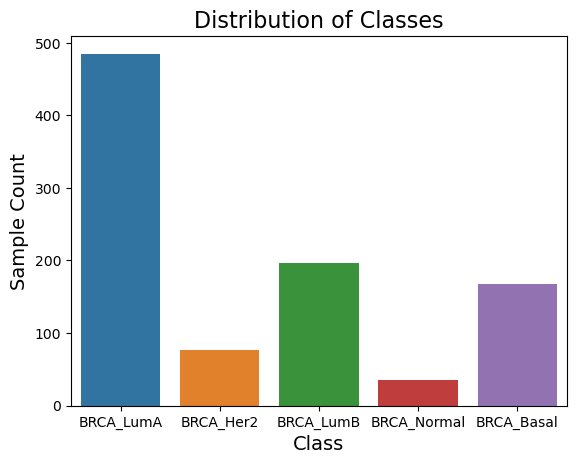

In [16]:
# Assuming 'subtype' is the column with your labels
sns.countplot(data=mofa_epigenomics, x='Subtype')  # Adjust 'subtype' if your label column has a different name
plt.title("Distribution of Classes", fontsize=16)
plt.xlabel('Class', fontsize=14)
plt.ylabel('Sample Count', fontsize=14)
plt.show()

In [17]:
# Step 1: Read the original data files
mofa_microbiomics = pd.read_csv("MOFA_Microbiome_matrix.csv", index_col=0)

# Check the dimensions of the dataframes
print("mofa_microbiomics shape:", mofa_microbiomics.shape)

mofa_microbiomics shape: (960, 101)


In [18]:
mofa_microbiomics.head()

,Lachnoclostridium,Terrabacter,Ruegeria,Tropicibacter,Marichromatium,Luteibacter,Prosthecomicrobium,Flammeovirga,Lymphocryptovirus,Actinopolymorpha,...,Natronolimnobius,Prasinovirus,Pleomorphomonas,Candidatus_Hepatobacter,Synergistes,Actinoplanes,Candidatus_Profftella,Marivirga,Dethiosulfatarculus,Subtype
Sample.ID,,,,,,,,,,,,,,,,,,,,,
TCGA.3C.AAAU.01,11.537331,18.444475,13.943300,2.379353,11.999489,14.844829,2.810667,1.326075,2.051468,1.361453,...,4.450246,0.299432,1.150041,1.874100,4.001890,5.147065,-0.474266,1.224097,3.883685,BRCA_LumA
TCGA.3C.AALI.01,11.613842,18.599329,14.167179,2.004074,12.875133,15.129347,3.168039,10.719479,2.404747,1.712497,...,4.807626,0.652197,1.506830,2.225793,4.356144,5.113261,-0.120748,1.576267,4.235966,BRCA_Her2
TCGA.3C.AALJ.01,11.785157,18.506904,14.256190,0.630921,10.863494,14.402245,3.384004,3.447369,2.638715,3.536684,...,5.030394,0.891748,3.315029,2.466130,4.592271,1.646944,2.437317,1.815482,4.474656,BRCA_LumB
TCGA.3C.AALK.01,10.164875,19.138499,14.464551,2.594400,11.162790,14.688892,2.560406,10.700237,1.860753,1.187517,...,5.800462,0.125859,0.918935,1.702080,5.404501,4.772491,-0.664564,1.047744,3.708987,BRCA_LumA
TCGA.4H.AAAK.01,11.649097,19.810779,14.244429,0.907614,10.968054,15.261712,3.412542,3.269998,1.659475,1.538255,...,4.892204,0.538413,2.673613,2.101231,4.765109,2.900931,-0.339855,1.454320,4.119472,BRCA_LumA


In [19]:
mofa_microbiomics.describe()

,Lachnoclostridium,Terrabacter,Ruegeria,Tropicibacter,Marichromatium,Luteibacter,Prosthecomicrobium,Flammeovirga,Lymphocryptovirus,Actinopolymorpha,...,Lactobacillus,Natronolimnobius,Prasinovirus,Pleomorphomonas,Candidatus_Hepatobacter,Synergistes,Actinoplanes,Candidatus_Profftella,Marivirga,Dethiosulfatarculus
count,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,...,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000
mean,11.232551,19.081341,14.247525,2.222638,11.529215,15.028641,3.463495,7.397012,1.738584,1.602282,...,11.534330,4.803209,0.187938,1.659871,1.838925,4.509673,4.649026,-0.104257,1.225586,3.733706
std,1.420591,0.744623,0.642106,1.666281,1.242144,0.475521,1.507369,3.288668,0.877262,0.760305,...,0.886886,1.330569,0.741882,1.257525,0.710392,0.825356,0.898753,0.860551,0.723169,0.738388
min,5.091674,16.444925,11.586120,-1.442815,7.733744,11.686283,1.019746,-0.701170,-0.399358,-0.500687,...,8.148987,2.347165,-1.859168,-0.180216,0.299541,2.352676,0.697183,-1.949610,-0.352136,2.017465
25%,10.396096,18.592699,13.835450,1.102841,10.666342,14.781262,2.266153,4.557504,1.204013,1.106506,...,11.041175,3.782928,-0.243795,0.693047,1.429806,3.944640,4.140683,-0.656156,0.783067,3.285640
50%,11.272705,19.063520,14.233175,2.349194,11.355663,15.015670,2.939325,8.268589,1.713350,1.437504,...,11.389322,4.475930,0.068417,1.199876,1.739307,4.303023,4.717526,-0.312949,1.072075,3.602626
75%,12.200771,19.549477,14.630661,3.446822,12.253248,15.246274,4.466366,9.996919,2.085687,1.843549,...,11.879853,5.578039,0.404161,2.486143,2.057851,4.816149,5.245262,0.127358,1.443608,3.981692
max,15.197834,21.840710,17.213071,6.255397,16.479884,18.172800,8.529740,13.917772,7.191281,5.764502,...,21.774420,10.700226,4.629345,7.027303,8.866983,7.729663,8.915938,6.405051,5.587419,8.197245


In [20]:
mofa_microbiomics.dtypes.value_counts()

float64    100
object       1
Name: count, dtype: int64

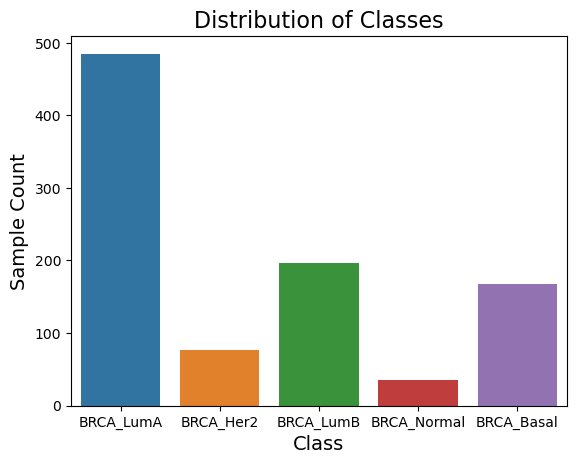

In [21]:
# Assuming 'subtype' is the column with your labels
sns.countplot(data=mofa_microbiomics, x='Subtype')  # Adjust 'subtype' if your label column has a different name
plt.title("Distribution of Classes", fontsize=16)
plt.xlabel('Class', fontsize=14)
plt.ylabel('Sample Count', fontsize=14)
plt.show()

In [22]:
def prepare_data(data):
    x = data.drop('Subtype', axis=1)
    y = data['Subtype']
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
    return X_train, X_test, y_train, y_test


In [23]:
# Define classifiers with hyperparameters
classifiers = {
    "SVM": SVC(probability=True, C=0.001, kernel='linear'),
    "Logistic Regression": LogisticRegression(max_iter=10000, C=0.01),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, max_depth=5),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5)
}

In [24]:
# Model evaluation function
def evaluate_models(X_train, X_test, y_train, y_test, classifiers):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    metrics_data = {key: {'Accuracy_train': [], 'F1_train': [], 'AUROC_train': [], 'MCC_train': [],
                          'Accuracy_test': [], 'F1_test': [], 'AUROC_test': [], 'MCC_test': []}
                    for key in classifiers.keys()}
    confusion_matrices = {name: np.zeros((len(np.unique(y_train)), len(np.unique(y_train)))) for name in classifiers}
    feature_importances = {}

    for name, clf in classifiers.items():
        for train_index, test_index in cv.split(X_train, y_train):
            x_train, x_test = X_train.iloc[train_index], X_train.iloc[test_index]
            y_train_fold, y_test_fold = y_train.iloc[train_index], y_train.iloc[test_index]

            pip = Pipeline([
                ('standardization', StandardScaler()),
                ('classification', clf)
            ])
            model = pip.fit(x_train, y_train_fold)
            pred_train = model.predict(x_train)
            pred_prob_train = model.predict_proba(x_train)
            pred_test = model.predict(x_test)
            pred_prob_test = model.predict_proba(x_test)

            # Collect metrics
            for kind, pred, pred_prob, true in [('train', pred_train, pred_prob_train, y_train_fold),
                                                ('test', pred_test, pred_prob_test, y_test_fold)]:
                metrics = metrics_data[name]
                metrics[f'Accuracy_{kind}'].append(accuracy_score(true, pred))
                metrics[f'F1_{kind}'].append(f1_score(true, pred, average='weighted'))
                metrics[f'AUROC_{kind}'].append(roc_auc_score(true, pred_prob, multi_class='ovo', average='macro'))
                metrics[f'MCC_{kind}'].append(matthews_corrcoef(true, pred))

            # Compute confusion matrix
            confusion_matrices[name] += confusion_matrix(y_test_fold, pred_test)

            # Collect feature importances
            if hasattr(clf, 'feature_importances_'):
                if name not in feature_importances:
                    feature_importances[name] = np.zeros(len(X_train.columns))
                feature_importances[name] += clf.feature_importances_ / cv.get_n_splits()
            elif hasattr(clf, 'coef_'):
                if name not in feature_importances:
                    feature_importances[name] = np.zeros(len(X_train.columns))
                feature_importances[name] += np.abs(clf.coef_[0]) / cv.get_n_splits()

    # Normalize confusion matrices
    for name in confusion_matrices:
        confusion_matrices[name] /= cv.get_n_splits()

    return metrics_data, confusion_matrices, feature_importances


In [25]:
def plot_metrics(metrics_data):
    num_metrics = 8  # Total number of metrics (4 training, 4 testing)
    num_models = len(metrics_data)
    fig, axs = plt.subplots(num_models, num_metrics, figsize=(20, num_models * 5))

    metric_names = ['Accuracy_train', 'F1_train', 'AUROC_train', 'MCC_train',
                    'Accuracy_test', 'F1_test', 'AUROC_test', 'MCC_test']

    for i, (name, metrics) in enumerate(metrics_data.items()):
        for j, metric_name in enumerate(metric_names):
            axs[i, j].bar(range(1, 6), metrics[metric_name], color='skyblue')
            axs[i, j].set_title(f'{name} - {metric_name}')
            axs[i, j].set_xticks(range(1, 6))
            axs[i, j].set_xticklabels(range(1, 6))
            axs[i, j].set_ylim([0, 1])  # Assuming metric values range from 0 to 1

    # Adjusting layout and labels
    for ax, metric in zip(axs[0], metric_names):
        ax.set_xlabel(metric)

    for ax, model_name in zip(axs[:, 0], classifiers.keys()):
        ax.set_ylabel(model_name, rotation=90, size='large')

    plt.tight_layout()
    plt.show()


In [26]:
# Print detailed results
def print_detailed_results(metrics_data):
    rows_list = []
    for name, metrics in metrics_data.items():
        num_folds = len(metrics['Accuracy_test'])  # Assuming all metric lists are of equal length
        for i in range(num_folds):
            row = {
                'Model': name,
                'Fold': i + 1,
                'Accuracy_test': metrics['Accuracy_test'][i],
                'F1_test': metrics['F1_test'][i],
                'AUROC_test': metrics['AUROC_test'][i],
                'MCC_test': metrics['MCC_test'][i]
            }
            rows_list.append(row)
    detailed_results_df = pd.DataFrame(rows_list)
    print(detailed_results_df)


In [27]:
# Plot feature importances
def plot_feature_importances(feature_importances, X_train):
    for name, importances in feature_importances.items():
        plt.figure(figsize=(8, 6))
        importances_series = pd.Series(importances, index=X_train.columns)
        importances_series.nlargest(10).plot.bar()
        plt.title(f"Feature Importances for {name}")
        plt.ylabel("Importance")
        plt.xlabel("Features")
        plt.tight_layout()
        plt.show()


In [28]:
# Display confusion matrices
def display_confusion_matrices(confusion_matrices):
    plt.figure(figsize=(12, 10))
    sns.set(style="whitegrid")
    for i, (name, matrix) in enumerate(confusion_matrices.items(), 1):
        plt.subplot(3, 3, i)  # Adjust subplot layout based on the number of classifiers
        sns.heatmap(matrix, annot=True, fmt=".0f", square=True, cmap="Blues", cbar=False)
        plt.title(name)
        plt.ylabel('Actual label')
        plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

In [29]:
# Datasets
datasets = {
    'All Omics': mofa_all_omic,
    'Transcriptomics': mofa_Transcriptomics,
    'Epigenomics': mofa_epigenomics,
    'Microbiomics': mofa_microbiomics
}

# Process each dataset
all_metrics = {}
all_conf_matrices = {}
all_feature_importances = {}
all_X_train = {}

Results for All Omics:


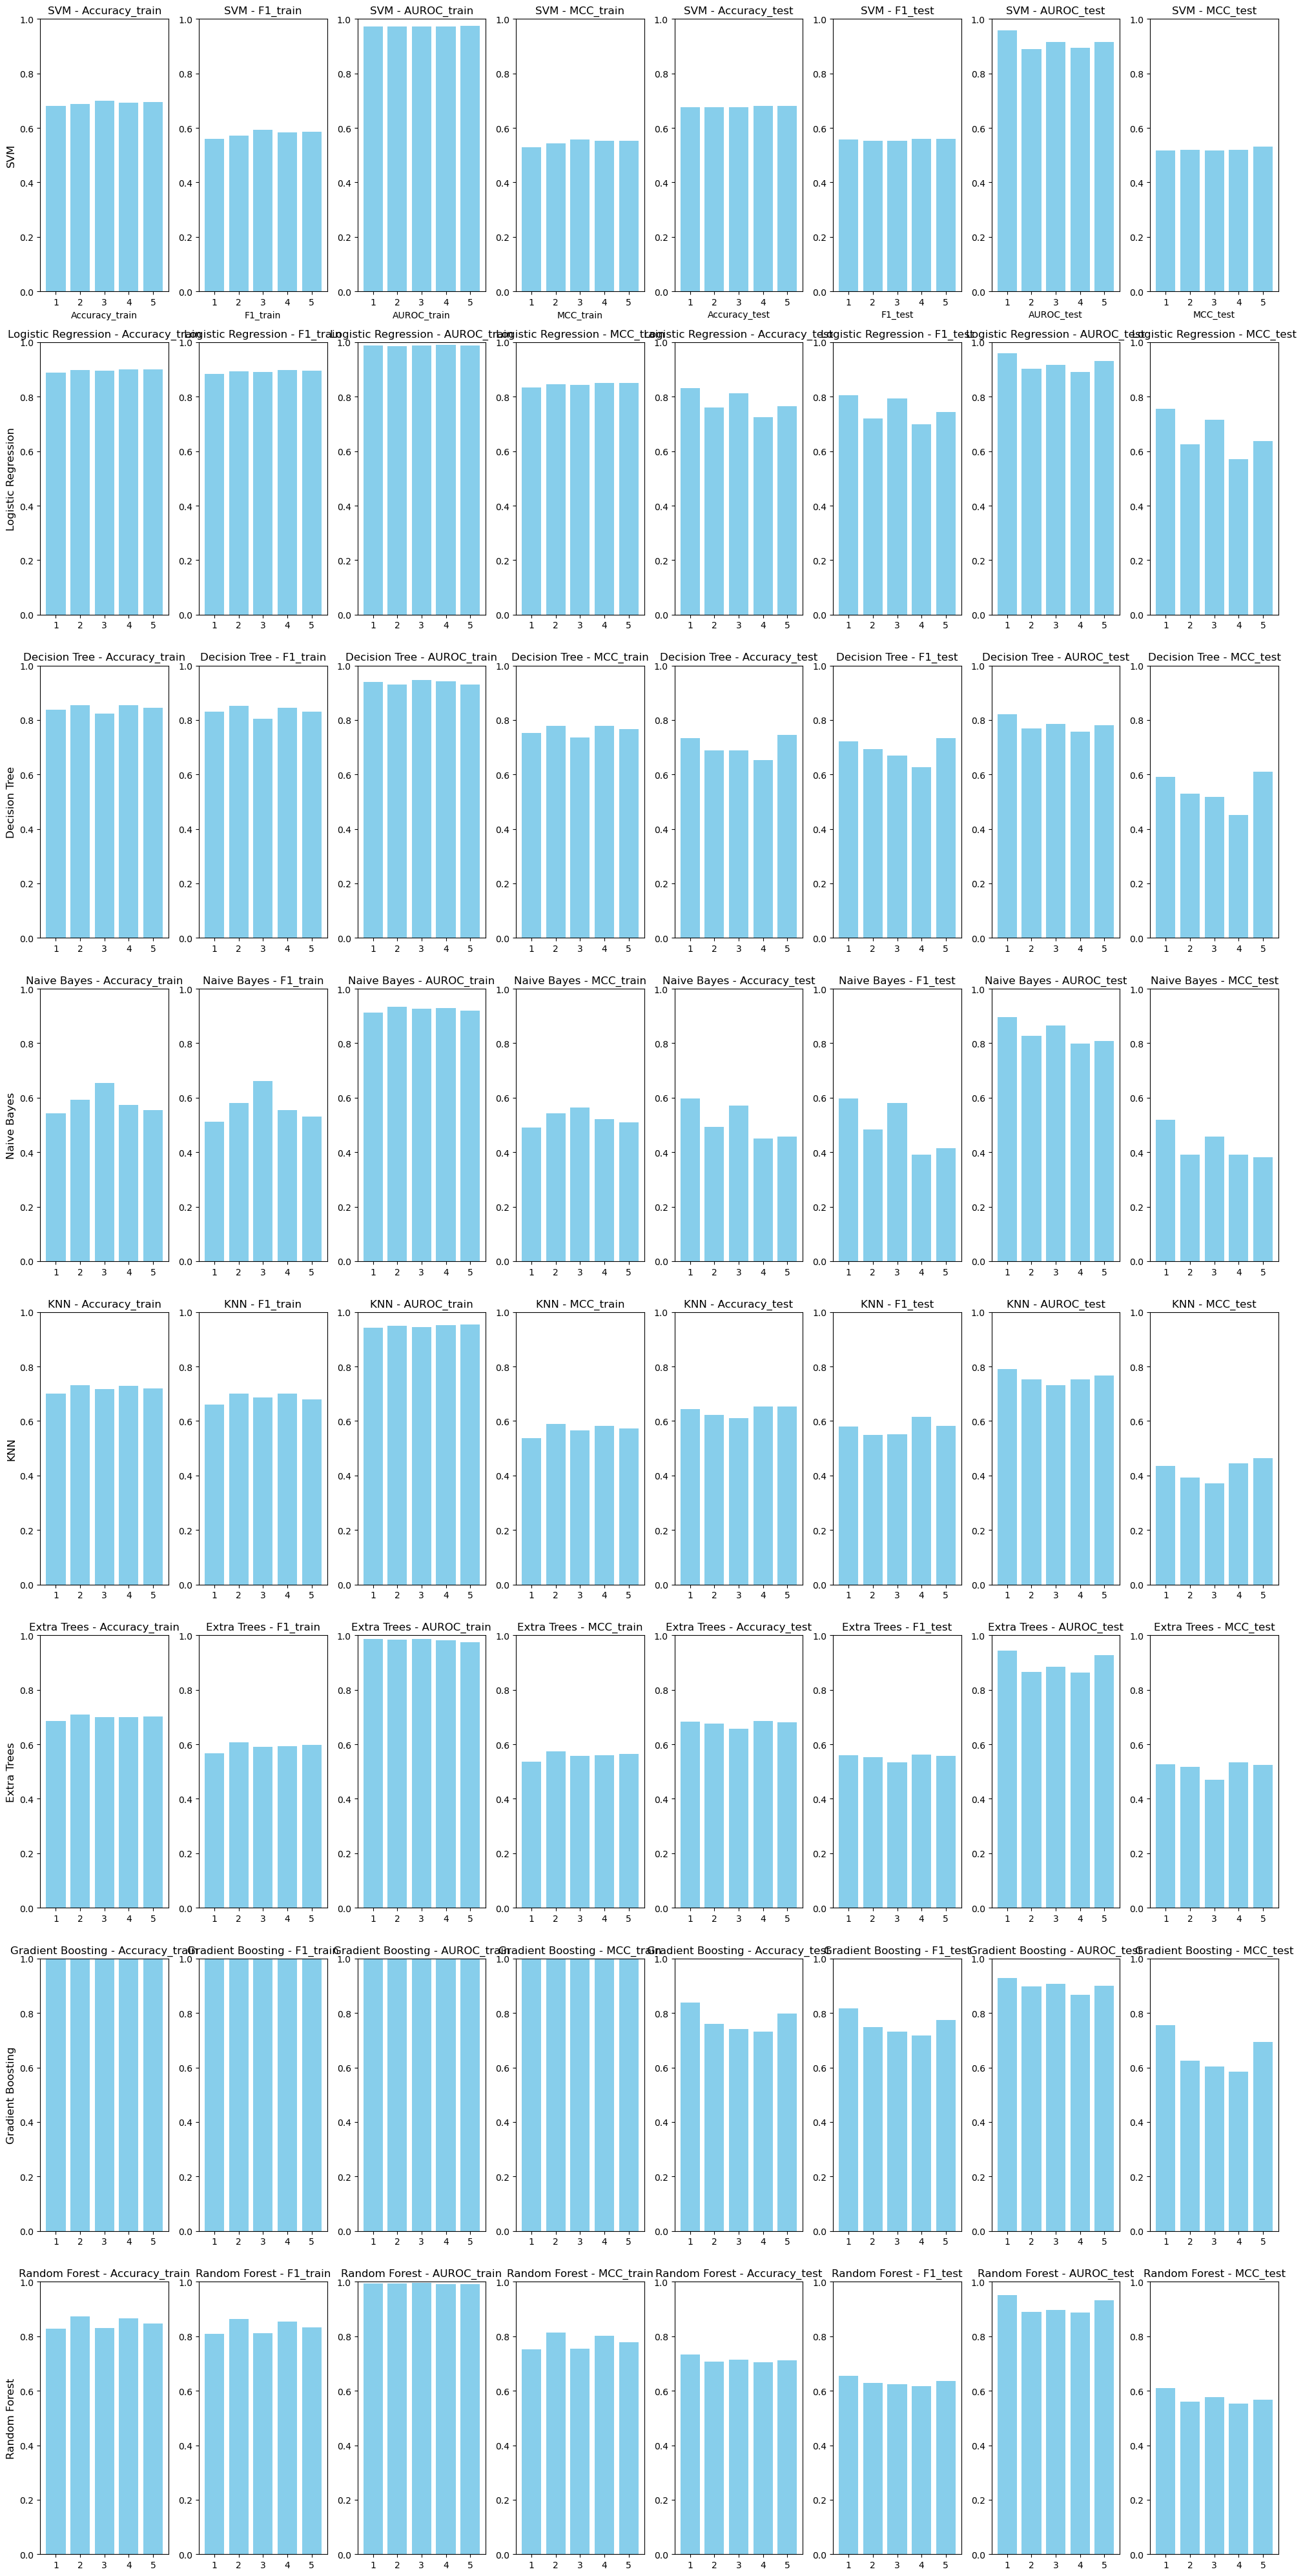

                  Model  Fold  Accuracy_test   F1_test  AUROC_test  MCC_test
0                   SVM     1       0.675325  0.556513    0.957052  0.518293
1                   SVM     2       0.675325  0.553437    0.888538  0.520246
2                   SVM     3       0.675325  0.552573    0.914784  0.516169
3                   SVM     4       0.679739  0.559849    0.895040  0.520003
4                   SVM     5       0.679739  0.559318    0.915092  0.530299
5   Logistic Regression     1       0.831169  0.805999    0.959845  0.756528
6   Logistic Regression     2       0.759740  0.721208    0.901627  0.625492
7   Logistic Regression     3       0.811688  0.793248    0.917138  0.714188
8   Logistic Regression     4       0.725490  0.699233    0.891389  0.569950
9   Logistic Regression     5       0.764706  0.743969    0.932113  0.636757
10        Decision Tree     1       0.733766  0.722030    0.821667  0.591491
11        Decision Tree     2       0.688312  0.691917    0.767864  0.528975

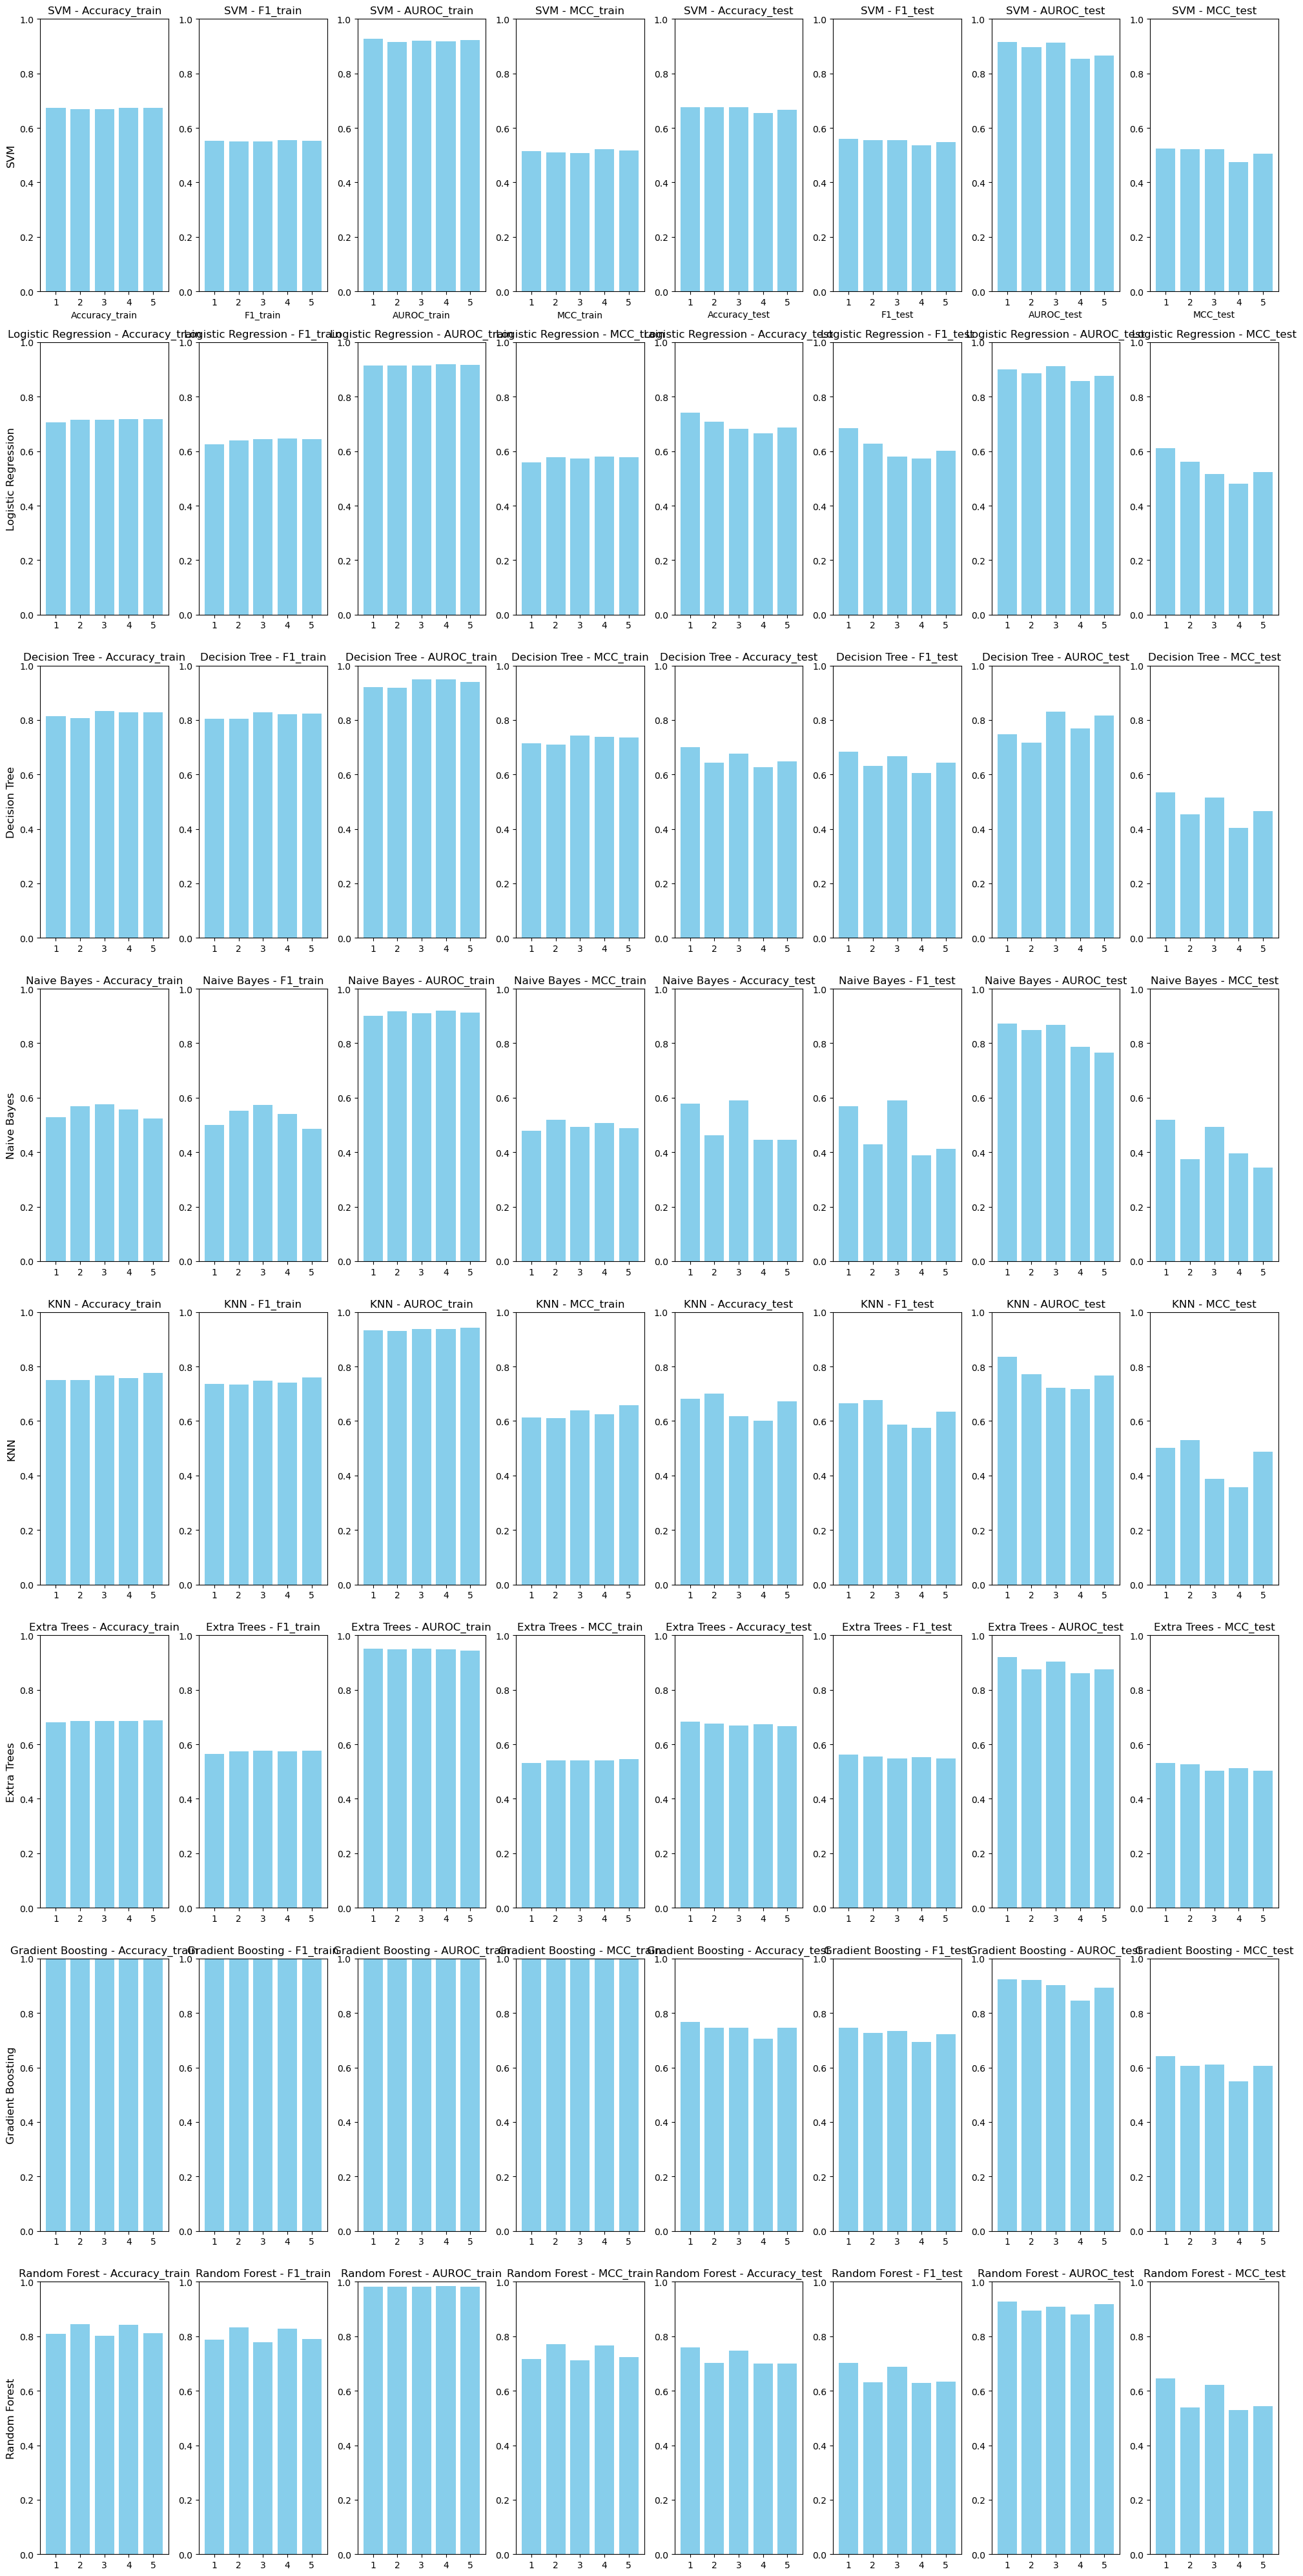

                  Model  Fold  Accuracy_test   F1_test  AUROC_test  MCC_test
0                   SVM     1       0.675325  0.559037    0.914784  0.523683
1                   SVM     2       0.675325  0.554635    0.896765  0.522717
2                   SVM     3       0.675325  0.554635    0.912747  0.522717
3                   SVM     4       0.653595  0.536901    0.854214  0.475115
4                   SVM     5       0.666667  0.548554    0.865587  0.506252
5   Logistic Regression     1       0.740260  0.685075    0.900812  0.611729
6   Logistic Regression     2       0.707792  0.628802    0.885458  0.560736
7   Logistic Regression     3       0.681818  0.581207    0.912569  0.515746
8   Logistic Regression     4       0.666667  0.572207    0.858376  0.481687
9   Logistic Regression     5       0.686275  0.601506    0.877305  0.523584
10        Decision Tree     1       0.701299  0.684087    0.748335  0.534227
11        Decision Tree     2       0.642857  0.631404    0.716521  0.452741

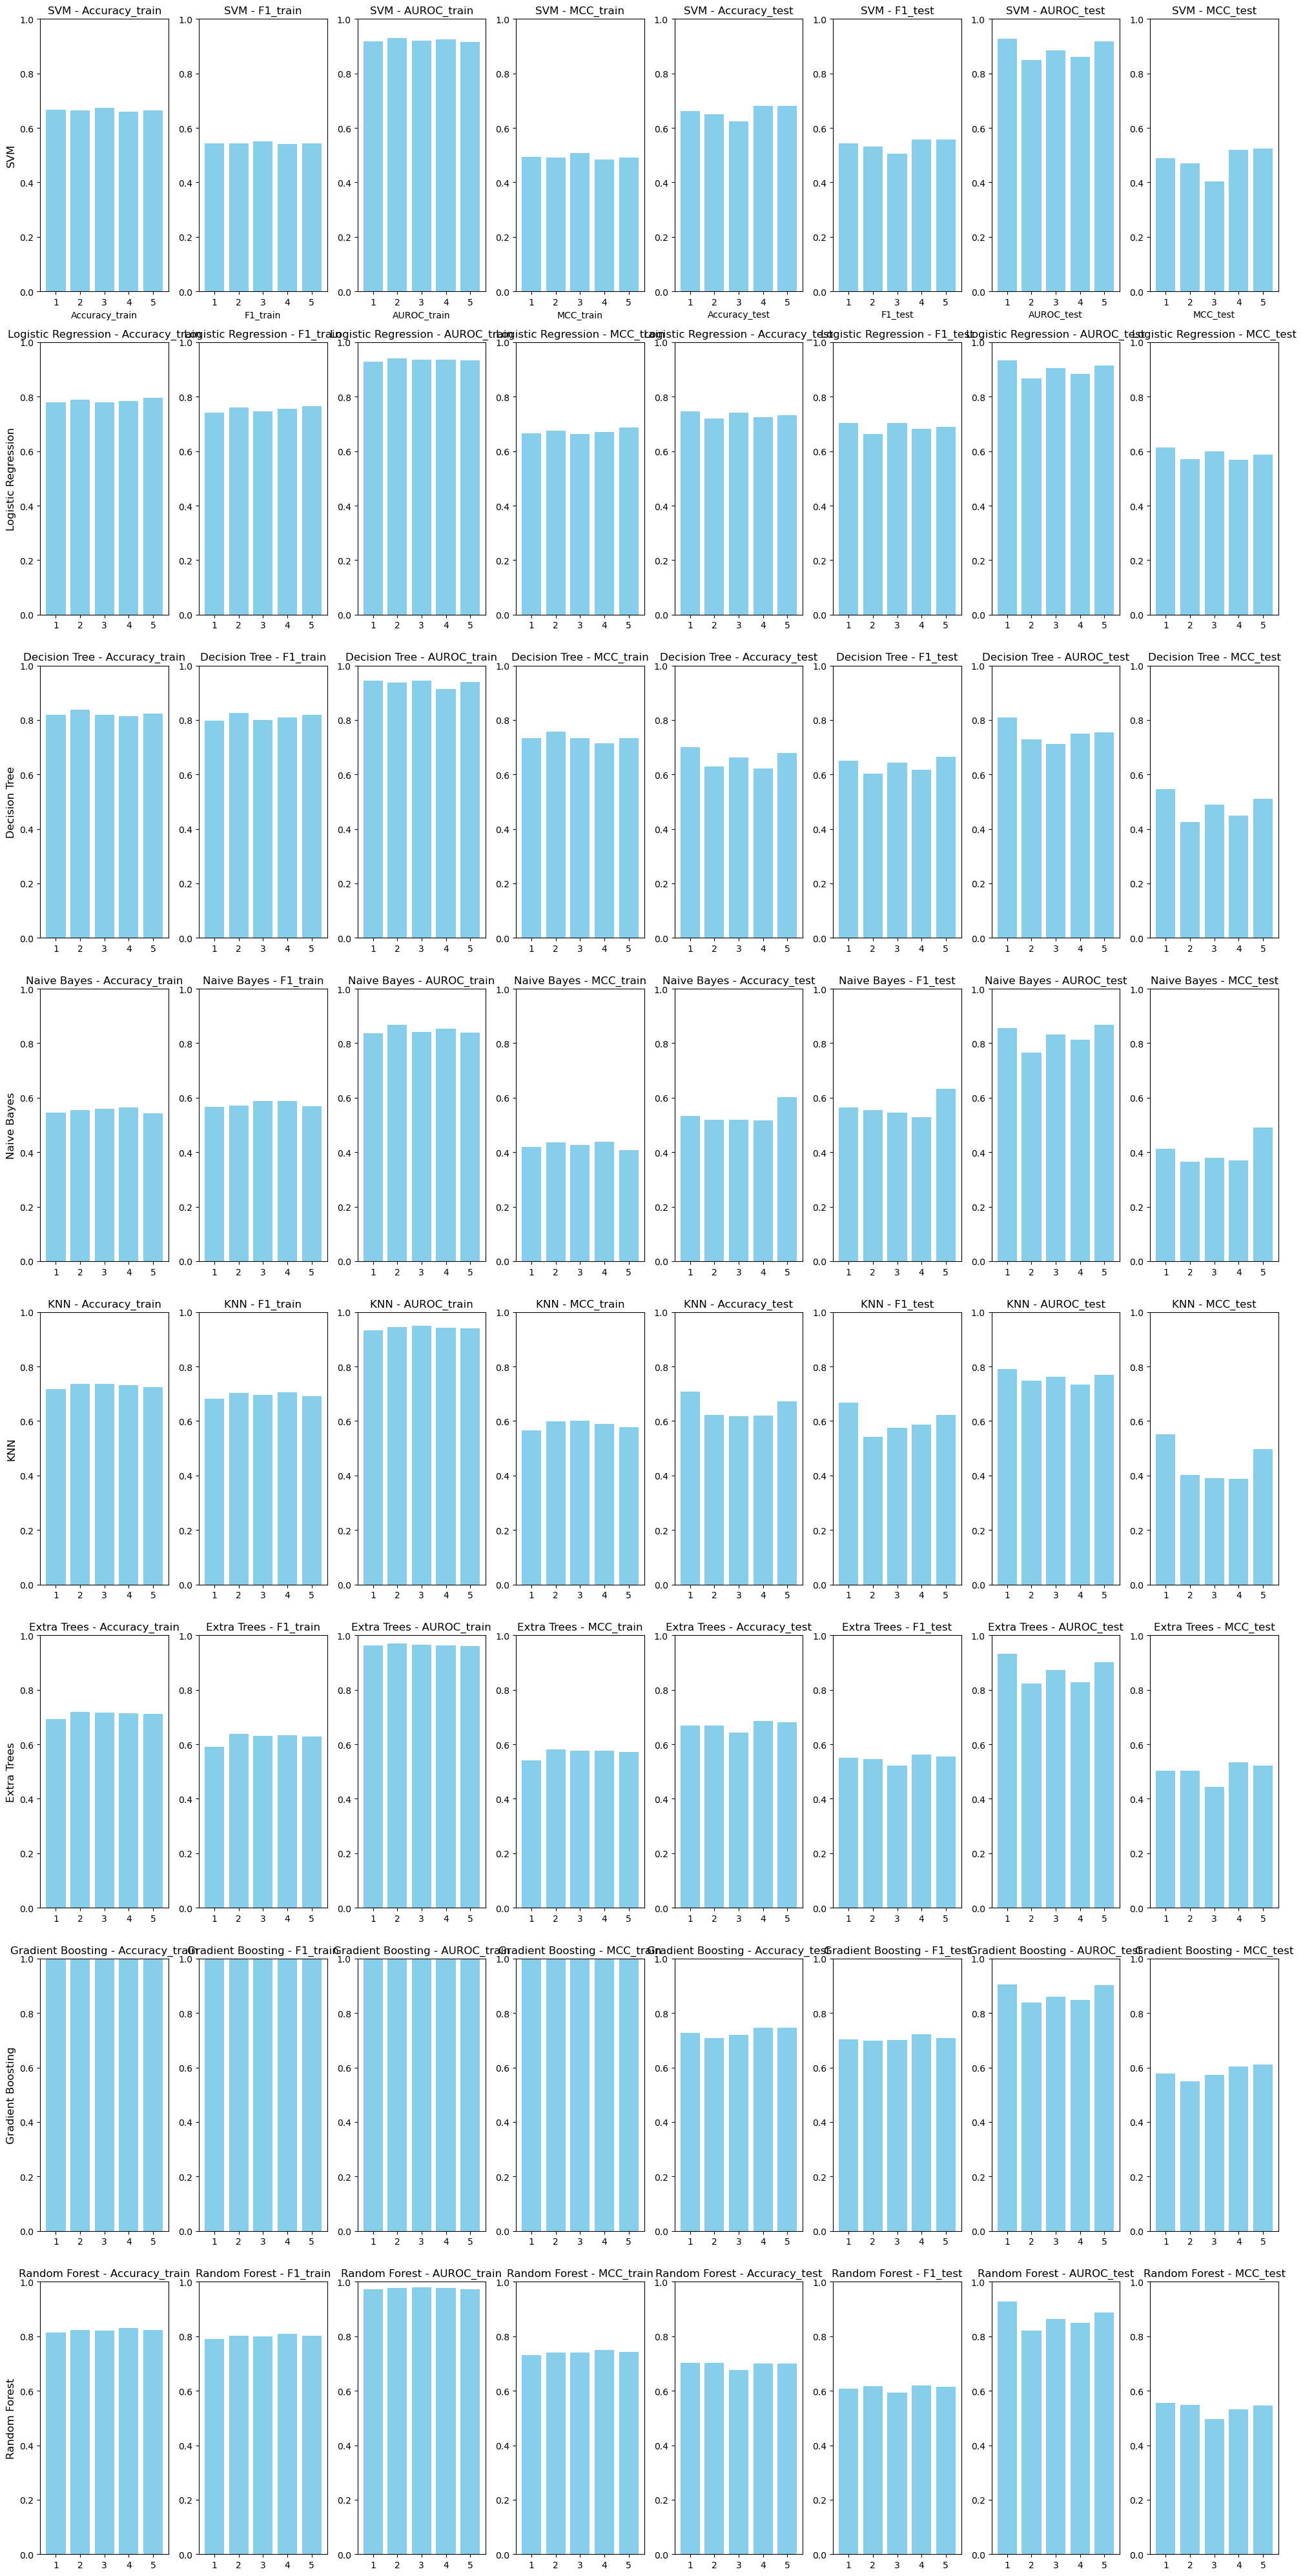

                  Model  Fold  Accuracy_test   F1_test  AUROC_test  MCC_test
0                   SVM     1       0.662338  0.543526    0.927546  0.489530
1                   SVM     2       0.649351  0.530492    0.848068  0.468706
2                   SVM     3       0.623377  0.505594    0.885534  0.404005
3                   SVM     4       0.679739  0.556961    0.859824  0.520495
4                   SVM     5       0.679739  0.556601    0.918826  0.523153
5   Logistic Regression     1       0.746753  0.702485    0.932680  0.614385
6   Logistic Regression     2       0.720779  0.664189    0.866260  0.570932
7   Logistic Regression     3       0.740260  0.702730    0.904764  0.600279
8   Logistic Regression     4       0.725490  0.682643    0.883064  0.569184
9   Logistic Regression     5       0.732026  0.689444    0.913893  0.587128
10        Decision Tree     1       0.701299  0.651502    0.809545  0.546318
11        Decision Tree     2       0.629870  0.602382    0.727965  0.424468

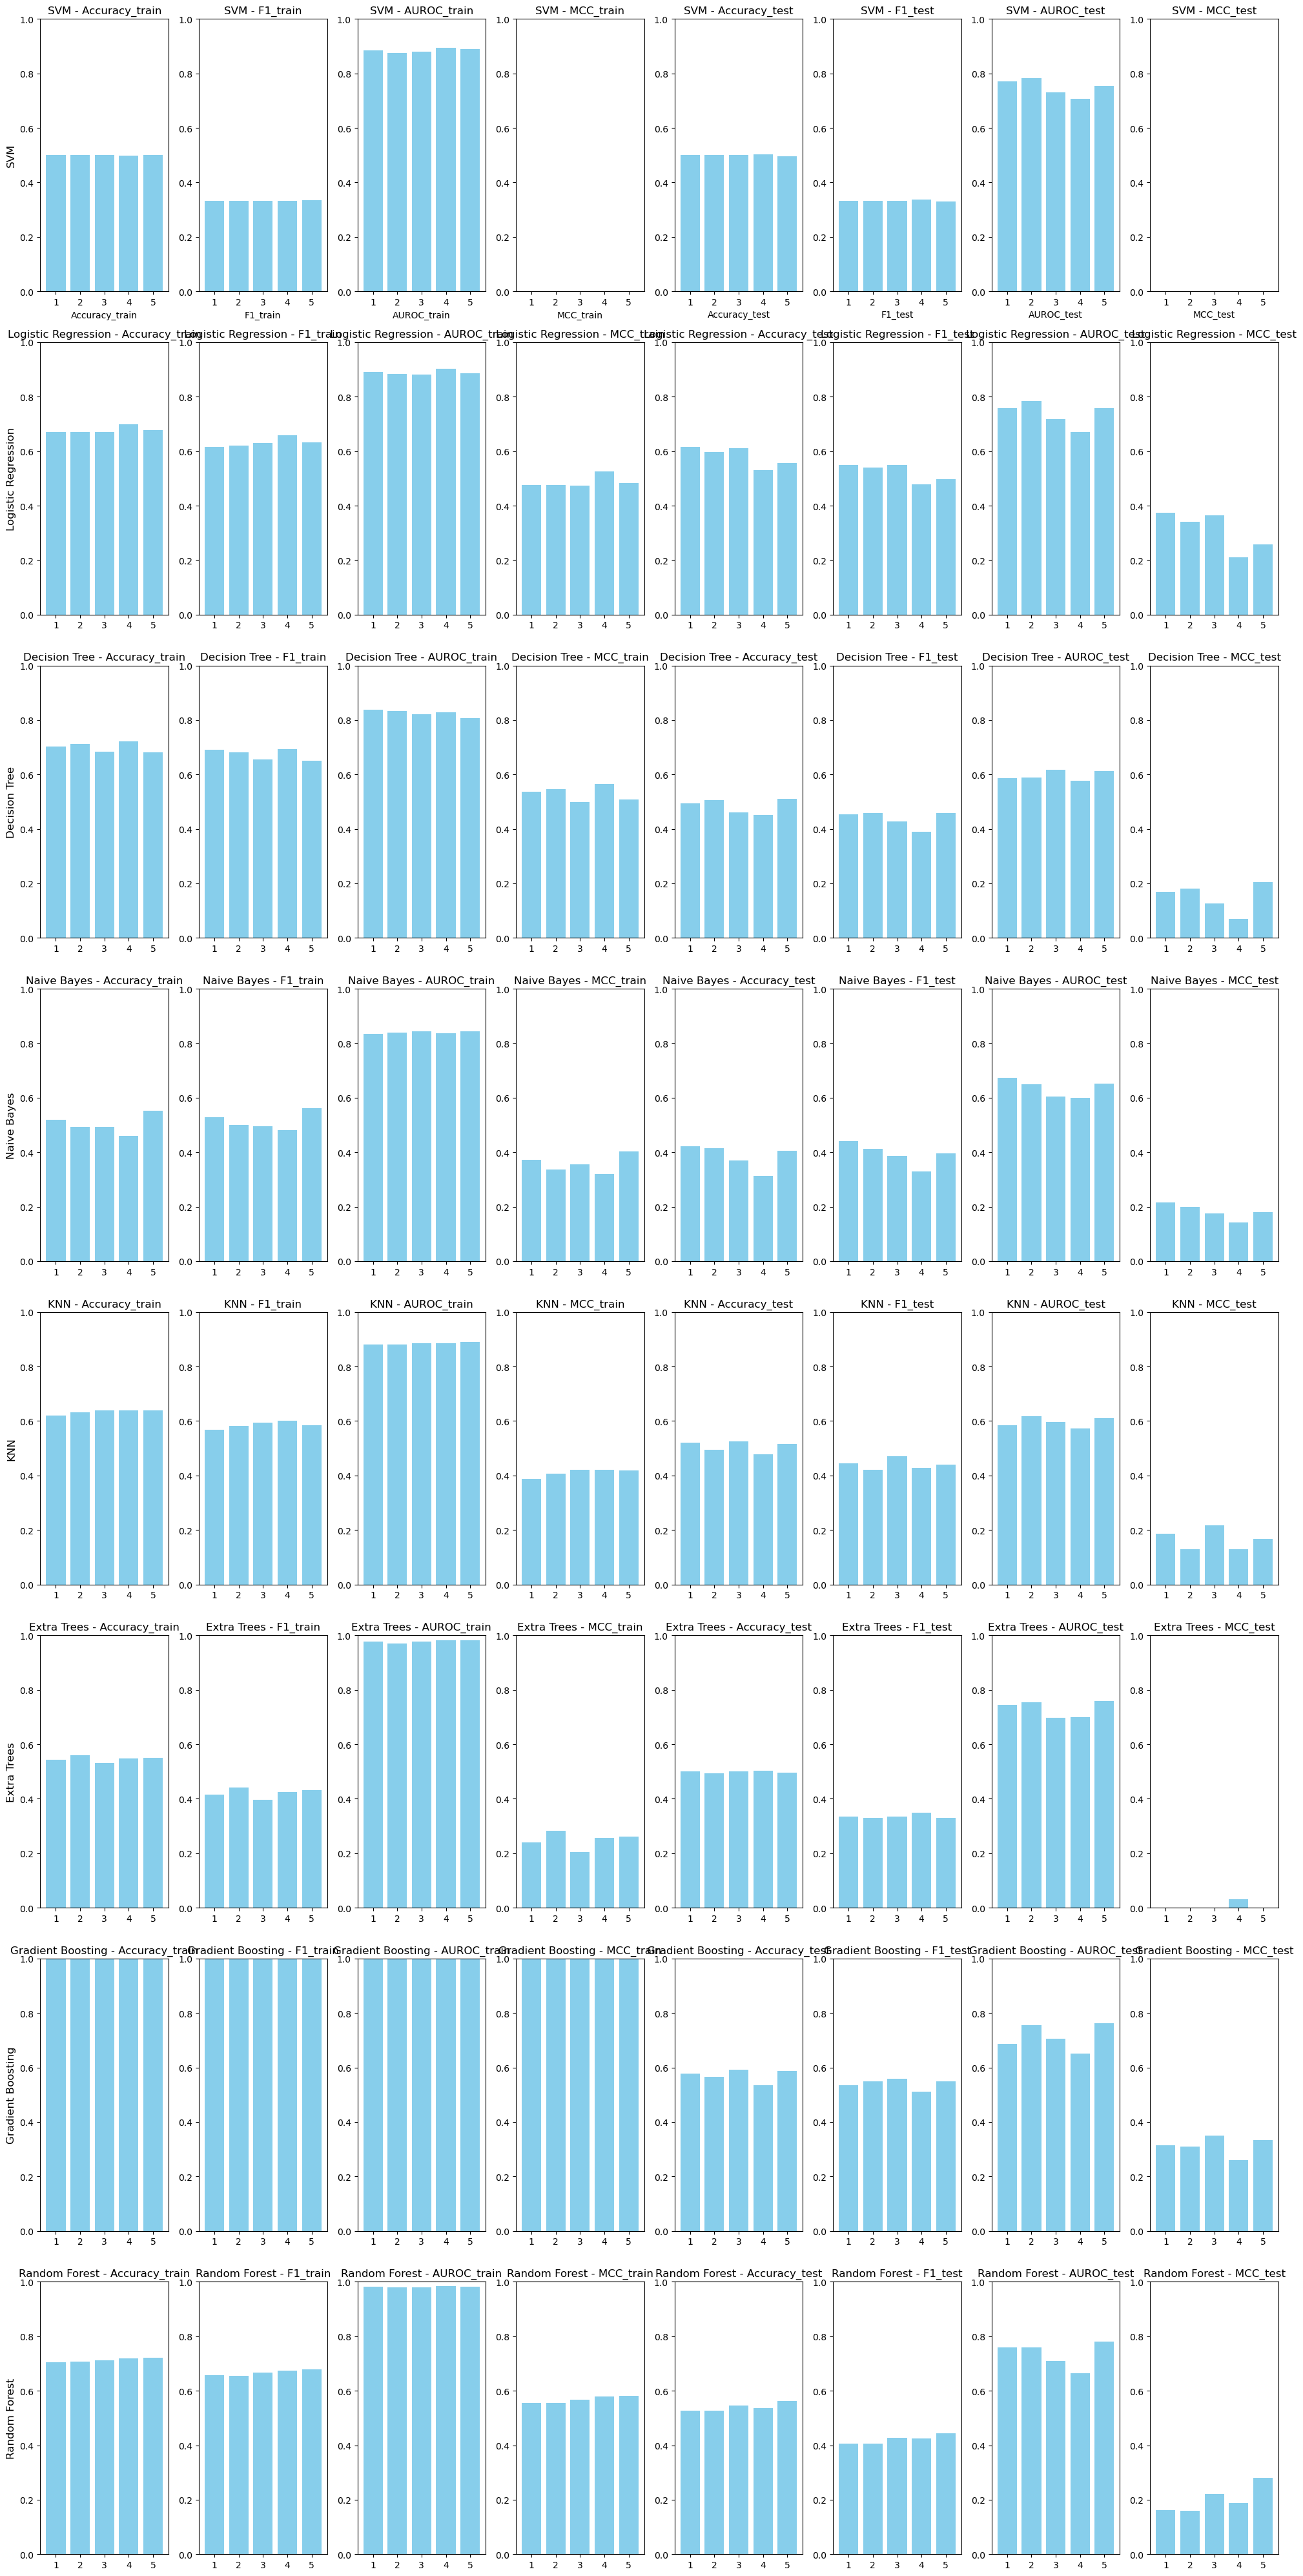

                  Model  Fold  Accuracy_test   F1_test  AUROC_test  MCC_test
0                   SVM     1       0.500000  0.333333    0.771861  0.000000
1                   SVM     2       0.500000  0.333333    0.782790  0.000000
2                   SVM     3       0.500000  0.333333    0.731104  0.000000
3                   SVM     4       0.503268  0.336971    0.707787  0.000000
4                   SVM     5       0.496732  0.329709    0.754131  0.000000
5   Logistic Regression     1       0.616883  0.548687    0.758753  0.374376
6   Logistic Regression     2       0.597403  0.540387    0.783908  0.340635
7   Logistic Regression     3       0.610390  0.548838    0.717629  0.363385
8   Logistic Regression     4       0.529412  0.478153    0.671043  0.209996
9   Logistic Regression     5       0.555556  0.497277    0.758117  0.257548
10        Decision Tree     1       0.493506  0.454532    0.585630  0.169562
11        Decision Tree     2       0.506494  0.457462    0.588007  0.181859

In [30]:
# Process each dataset
datasets = {
    'All Omics': mofa_all_omic,
    'Transcriptomics': mofa_Transcriptomics,
    'Epigenomics': mofa_epigenomics,
    'Microbiomics': mofa_microbiomics
}
all_metrics = {}
all_conf_matrices = {}
all_feature_importances = {}
all_X_train = {}

for name, data in datasets.items():
    X_train, X_test, y_train, y_test = prepare_data(data)
    metrics, conf_matrices, feat_importances = evaluate_models(X_train, X_test, y_train, y_test, classifiers)
    
    all_metrics[name] = metrics
    all_conf_matrices[name] = conf_matrices
    all_feature_importances[name] = feat_importances
    all_X_train[name] = X_train

    # Print detailed results
    print(f"Results for {name}:")
    plot_metrics(metrics)
    print_detailed_results(metrics)


In [31]:
# Function to print detailed metrics for each dataset and model
def print_detailed_metrics(all_metrics):
    print("Detailed Metrics Matrix:\n")
    for dataset_name, metrics_data in all_metrics.items():
        print(f"Dataset: {dataset_name}\n")
        for model_name, metrics in metrics_data.items():
            print(f"Model: {model_name}")
            for metric_type, values in metrics.items():
                print(f"  {metric_type}: {np.mean(values):.4f} ± {np.std(values):.4f}")
            print("\n")

# Assuming 'all_metrics' is filled with data from all datasets
print_detailed_metrics(all_metrics)

Detailed Metrics Matrix:

Dataset: All Omics

Model: SVM
  Accuracy_train: 0.6911 ± 0.0060
  F1_train: 0.5788 ± 0.0119
  AUROC_train: 0.9728 ± 0.0009
  MCC_train: 0.5470 ± 0.0099
  Accuracy_test: 0.6771 ± 0.0022
  F1_test: 0.5563 ± 0.0030
  AUROC_test: 0.9141 ± 0.0239
  MCC_test: 0.5210 ± 0.0049


Model: Logistic Regression
  Accuracy_train: 0.8968 ± 0.0043
  F1_train: 0.8921 ± 0.0048
  AUROC_train: 0.9883 ± 0.0012
  MCC_train: 0.8450 ± 0.0061
  Accuracy_test: 0.7786 ± 0.0380
  F1_test: 0.7527 ± 0.0410
  AUROC_test: 0.9204 ± 0.0241
  MCC_test: 0.6606 ± 0.0665


Model: Decision Tree
  Accuracy_train: 0.8424 ± 0.0119
  F1_train: 0.8328 ± 0.0161
  AUROC_train: 0.9375 ± 0.0067
  MCC_train: 0.7622 ± 0.0169
  Accuracy_test: 0.7018 ± 0.0334
  F1_test: 0.6883 ± 0.0385
  AUROC_test: 0.7824 ± 0.0218
  MCC_test: 0.5395 ± 0.0566


Model: Naive Bayes
  Accuracy_train: 0.5833 ± 0.0395
  F1_train: 0.5678 ± 0.0515
  AUROC_train: 0.9241 ± 0.0076
  MCC_train: 0.5254 ± 0.0260
  Accuracy_test: 0.5142 ± 0.